# 📥 Imports

In [ ]:
import gdown
import pandas as pd
import numpy as np
from scipy.stats import poisson
from scipy.stats import chisquare
from scipy.optimize import minimize
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# 📁 Dataset

In [ ]:
df = pd.read_csv('../Dataset/futebol-bra.csv')
df

,Country,League,Season,Date,Time,Home,Away,HG,AG,Res,...,MaxCA,AvgCH,AvgCD,AvgCA,BFECH,BFECD,BFECA,B365CH,B365CD,B36CA
0,Brazil,Serie A,2012,19/05/2012,22:30,Palmeiras,Portuguesa,1.0,1.0,D,...,5.31,1.69,3.50,4.90,NaN,NaN,NaN,NaN,NaN,NaN
1,Brazil,Serie A,2012,19/05/2012,22:30,Sport Recife,Flamengo RJ,1.0,1.0,D,...,2.70,2.59,3.23,2.58,NaN,NaN,NaN,NaN,NaN,NaN
2,Brazil,Serie A,2012,20/05/2012,01:00,Figueirense,Nautico,2.0,1.0,H,...,7.22,1.59,3.67,5.64,NaN,NaN,NaN,NaN,NaN,NaN
3,Brazil,Serie A,2012,20/05/2012,20:00,Botafogo RJ,Sao Paulo,4.0,2.0,H,...,3.15,2.35,3.26,2.84,NaN,NaN,NaN,NaN,NaN,NaN
4,Brazil,Serie A,2012,20/05/2012,20:00,Corinthians,Fluminense,0.0,1.0,A,...,4.41,1.89,3.33,3.89,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5144,Brazil,Serie A,2025,31/08/2025,22:30,Corinthians,Palmeiras,1.0,1.0,D,...,2.20,3.62,3.04,2.16,3.95,3.15,2.30,3.70,3.0,2.15
5145,Brazil,Serie A,2025,31/08/2025,22:30,Mirassol,Bahia,5.0,1.0,H,...,3.30,2.26,3.22,3.16,2.40,3.35,3.40,2.35,3.2,3.20
5146,Brazil,Serie A,2025,31/08/2025,22:30,Vitoria,Atletico-MG,1.0,0.0,H,...,2.42,3.25,3.01,2.34,3.55,3.10,2.48,3.50,3.0,2.30
5147,Brazil,Serie A,2025,01/09/2025,00:30,Internacional,Fortaleza,2.0,1.0,H,...,5.75,1.62,3.81,5.36,1.68,3.95,6.20,1.62,3.8,5.75


In [ ]:
df['Home'] = df['Home'].replace({'Atletico-PR': 'Athletico-PR'})
df['Away'] = df['Away'].replace({'Atletico-PR': 'Athletico-PR'})
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# 📊 Modelo de Poisson

Distribuição de probabilidade discreta que expressa a probabilidade de um número dado de eventos ocorrer em um intervalo fixo de tempo ou espaço.

Calcular a probabilidade de um evento acontecer, baseado nos anteriores.

---

**Características**

* Eventos Raros: A Distribuição de Poisson é adequada para modelar eventos que ocorrem com baixa frequência.
* Independência: a ocorrência de um evento não deve afetar a probabilidade de ocorrência de outro evento.
* Taxa Constante: A taxa média de ocorrência dos eventos deve ser constante ao longo do intervalo de tempo ou espaço considerado.
* Distribuição Discreta: a variável aleatória assume apenas valores inteiros não negativos.

---

**Fórmula**

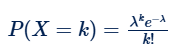

* P(X=k): é a probabilidade de observar k eventos em um intervalo.
* λ: é a taxa média de eventos por intervalo.
* k: é o número de eventos observados.
* e: é a base do logaritmo natural (aproximadamente 2.71828).

---

Exemplo para calcular a probabilidade de um time fazer X gols:

O time faz em média 1 gol por partida, para calcular qual a probabilidade dele fazer 3 gols em uma partida, aplica-se na fórmula:

P(X=3) = 1³ * e-¹ / 3!

---

Já para montar a matriz, depois de ter calculado a média de gols dos times, é feito este cálculo:

**P(placar=x x y) = Pcasa​(X=x) * Pfora​(Y=y)**

Onde:
* X: gols do time da casa
* Y: gols do time de fora
* Pcasa​(X=x): probabilidade do time da casa marcar 𝑥 gols (Poisson)
* Pcasa​(Y=y): probabilidade do time visitante marcar y gols (Poisson)

Exemplo:

λ casa = 1.5

λ fora = 1.0

P(2,1) = 1.5² * e^-1.5 / 2! * 1¹ * e^-1 / 1!

In [ ]:
df_poisson = df[['Home', 'Away', 'HG', 'AG']]
df_poisson.head()

,Home,Away,HG,AG
0,Palmeiras,Portuguesa,1.0,1.0
1,Sport Recife,Flamengo RJ,1.0,1.0
2,Figueirense,Nautico,2.0,1.0
3,Botafogo RJ,Sao Paulo,4.0,2.0
4,Corinthians,Fluminense,0.0,1.0


In [ ]:
# Renomeando as colunas
goal_model_data = pd.concat([df_poisson[['Home','Away','HG']].assign(home=1).rename(columns={'Home':'team', 'Away':'opponent','HG':'goals'}),
           df_poisson[['Away','Home','AG']].assign(home=0).rename(columns={'Away':'team', 'Home':'opponent','AG':'goals'})])

# Biblioteca que possui o modelo de Poisson
poisson_model = smf.glm(formula="goals ~ home + team + opponent", data=goal_model_data,
                        family=sm.families.Poisson()).fit()

In [ ]:
# Função que simula uma partida, fornecendo a médias de gols do time mandante e visitante
# 1. Estima a média de gols de cada time
# 2. Para cada média de gols, calcula as probabilidades de fazer de 0 a max_goals
# 3. Cria uma matriz de probabilidades combinadas, onde cada célula [i][j] é a probabilidade de: Time da casa fazer i gols e Time visitante fazer j gols
# O time mandante representa as linhas da matriz, o visitante representa as colunas e a diagonal são os empates

def poisson_simulate_match(foot_model, homeTeam, awayTeam, max_goals=5):
    home_goals_avg = foot_model.predict(pd.DataFrame(data={'team': homeTeam,
                                                            'opponent': awayTeam,'home':1},
                                                      index=[1])).values[0]
    away_goals_avg = foot_model.predict(pd.DataFrame(data={'team': awayTeam,
                                                            'opponent': homeTeam,'home':0},
                                                      index=[1])).values[0]
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [home_goals_avg, away_goals_avg]]
    return(np.outer(np.array(team_pred[0]), np.array(team_pred[1])))

# 📈 Dixon-Coles

O modelo de Dixon-Coles é uma extensão do modelo de Poisson e foi desenvolvido para abordar limitações do modelo de Poisson simples, como a superestimação da frequência de empates e de placares baixo, e para incorporar variações temporais no desempenho das equipes.

O modelo assume que o número de gols marcados por cada time segue uma distribuição de Poisson, mas com três principais ajustes:

* Parâmetros de ataque e defesa para cada time: cada equipe possui uma força ofensiva (ataque) e uma fraqueza defensiva (defesa). Esses parâmetros são estimados a partir de dados históricos e refletem a qualidade relativa da equipe.

* Fator de vantagem de jogar em casa: é incluído um termo extra para refletir a vantagem do mandante.

* Correção de dependência para placares baixos: o modelo introduz um parâmetro ρ (rho), que ajusta a probabilidade conjunta para empates de placares baixos.

* Decaimento temporal (opcional): para refletir que jogos mais recentes são mais relevantes, pode-se aplicar um fator de decaimento exponencial aos dados históricos.

---

**Fórmula**

λij = αi + βj​ + γ

μij​ = αj + βi

Onde:
* αi: parâmetro de ataque do time i (o quanto um time costuma marcar).
* βi: parâmetro de defesa do time j (o quanto um time costuma sofrer).
* γ: vantagem de jogar em casa.

Estes parâmetros não são “calculados diretamente”, mas estimados via regressão de Poisson.

Descrito nestes termos (função de probabilidade conjunta de duas variáveis, cada uma com distribuição de Poisson e com uma função de dependência):

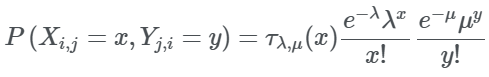

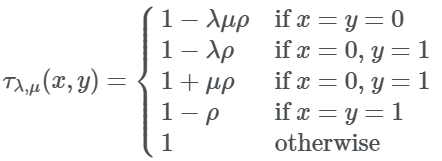

A principal diferença é a adição do τ. É altamente dependente do ρ parâmetro (rho), que controla a intensidade da correção (rho_correction).

Verossimilhança ajustada: construída a partir das distribuições de Poisson de gols de mandante e visitante, incorporando a função de correção 𝜏 (ou ρ-correction) para ajustar a dependência entre as duas distribuições.

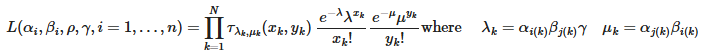

In [ ]:
# Ajustando o dataset para pegar os jogos apenas do ano de 2024 e 2025, alterando o nome das colunas e excluindo as linhas onde há algum valor nulo nos campos Home, Away, HG ou AG
df_recent = df[df['Date'].dt.year >= 2024]

df_dixon = df_recent[['Home', 'Away', 'HG', 'AG', 'Date']].copy()
df_dixon = df_dixon.dropna(subset=['Home', 'Away', 'HG', 'AG'])

df_dixon

,Home,Away,HG,AG,Date
4560,Criciuma,Juventude,1.0,1.0,2024-04-13
4561,Internacional,Bahia,2.0,1.0,2024-04-13
4562,Fluminense,Bragantino,2.0,2.0,2024-04-14
4563,Sao Paulo,Fortaleza,1.0,2.0,2024-04-14
4564,Athletico-PR,Cuiaba,4.0,0.0,2024-04-14
...,...,...,...,...,...
5144,Corinthians,Palmeiras,1.0,1.0,2025-08-31
5145,Mirassol,Bahia,5.0,1.0,2025-08-31
5146,Vitoria,Atletico-MG,1.0,0.0,2025-08-31
5147,Internacional,Fortaleza,2.0,1.0,2025-09-01


In [ ]:
# Ajuste de correlação de baixa contagem
def rho_correction(x, y, lambda_x, mu_y, rho):
    if x==0 and y==0:
        return 1- (lambda_x * mu_y * rho)
    elif x==0 and y==1:
        return 1 + (lambda_x * rho)
    elif x==1 and y==0:
        return 1 + (mu_y * rho)
    elif x==1 and y==1:
        return 1 - rho
    else:
        return 1.0

# Função de verossimilhança (log-likelihood)
# Mede a adequação do modelo aos dados observados
def dc_log_like(x, y, alpha_x, beta_x, alpha_y, beta_y, rho, gamma):
    # λ (média de gols do time da casa) e μ (média de gols do time visitante)
    lambda_x, mu_y = np.exp(alpha_x + beta_y + gamma), np.exp(alpha_y + beta_x)
    return (np.log(max(rho_correction(x, y, lambda_x, mu_y, rho), 1e-10)) +
            np.log(max(poisson.pmf(x, lambda_x), 1e-10)) +
            np.log(max(poisson.pmf(y, mu_y), 1e-10)))

# Função para estimar os parâmetros do modelo
def solve_parameters(dataset, debug=False, init_vals=None, options={'disp': True, 'maxiter':100}, **kwargs):
    teams = np.sort(dataset['Home'].unique())
    away_teams = np.sort(dataset['Away'].unique())

    n_teams = len(teams)

    # Inicialização dos parâmetros (ataque, defesa, rho e vantagem de casa)
    if init_vals is None:
        init_vals = np.concatenate((
            np.random.normal(0, 0.1, n_teams),  # ataque
            np.random.normal(0, 0.1, n_teams),  # defesa
            np.array([0.0, 0.1])                # rho, home_adv
        ))

    # Restrições: a soma dos parâmetros de ataque e defesa deve ser 0
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x[:n_teams])},
        {'type': 'eq', 'fun': lambda x: np.sum(x[n_teams:2*n_teams])}
    ]

    # Bounds para evitar explosão
    bounds = [(-3, 3)] * (2*n_teams) + [(-1, 1), (-2, 2)]

    # Função interna que calcula o valor negativo da log-verossimilhança
    def estimate_parameters(params):
        score_coefs = dict(zip(teams, params[:n_teams]))
        defend_coefs = dict(zip(teams, params[n_teams:(2*n_teams)]))
        rho, gamma = params[-2:]

        # Calcula log-verossimilhança para todas as partidas do dataset
        log_like = [
            dc_log_like(
                row.HG, row.AG,
                score_coefs[row.Home], defend_coefs[row.Home],
                score_coefs[row.Away], defend_coefs[row.Away],
                rho, gamma
            )
            for row in dataset.itertuples()
        ]
        return -np.sum(log_like)

    # Otimização
    opt_output = minimize(
        estimate_parameters,
        init_vals,
        options=options,
        constraints=constraints,
        bounds=bounds,
        **kwargs
    )

    if debug:
        return opt_output
    else:
        return dict(zip(
            ["attack_"+team for team in teams] +
            ["defence_"+team for team in teams] +
            ['rho', 'home_adv'],
            opt_output.x
        ))

In [ ]:
# Estimar os parâmetros
params = solve_parameters(df_dixon)
params

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1578.1423061243304
            Iterations: 60
            Function evaluations: 3152
            Gradient evaluations: 60


{'attack_Athletico-PR': np.float64(-0.1007029032074999),
 'attack_Atletico GO': np.float64(-0.40023648936131295),
 'attack_Atletico-MG': np.float64(0.016463458031794134),
 'attack_Bahia': np.float64(0.1322797617712725),
 'attack_Botafogo RJ': np.float64(0.2532766926303307),
 'attack_Bragantino': np.float64(0.03660884762499659),
 'attack_Ceara': np.float64(-0.26071346093489317),
 'attack_Corinthians': np.float64(0.09837398273751322),
 'attack_Criciuma': np.float64(-0.03437559905864659),
 'attack_Cruzeiro': np.float64(0.10064625742227162),
 'attack_Cuiaba': np.float64(-0.40813419032710796),
 'attack_Flamengo RJ': np.float64(0.41725253068084356),
 'attack_Fluminense': np.float64(-0.16143551450662993),
 'attack_Fortaleza': np.float64(0.0710598874549297),
 'attack_Gremio': np.float64(-0.06831006232463298),
 'attack_Internacional': np.float64(0.1288470511065124),
 'attack_Juventude': np.float64(-0.004604618037175089),
 'attack_Mirassol': np.float64(0.40473271482578044),
 'attack_Palmeiras': 

In [ ]:
# Calcula médias de gols esperados para um confronto
def calc_means(param_dict, homeTeam, awayTeam):
    return [np.exp(param_dict['attack_'+homeTeam] + param_dict['defence_'+awayTeam] + param_dict['home_adv']),
            np.exp(param_dict['attack_'+awayTeam] + param_dict['defence_'+homeTeam])]

# Simula distribuição de placares para uma partida
# Cria uma matriz de probabilidades combinadas, onde cada célula [i][j] é a probabilidade de: Time da casa fazer i gols e Time visitante fazer j gols
# O time mandante representa as linhas da matriz, o visitante representa as colunas e a diagonal são os empates
def dixon_coles_simulate_match(params_dict, homeTeam, awayTeam, max_goals=10):
    # Médias de gols esperados
    team_avgs = calc_means(params_dict, homeTeam, awayTeam)

    # Probabilidade de cada número de gols (0 até max_goals) para cada time
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in team_avgs]

    # Matriz de probabilidades cruzadas (casa x fora)
    output_matrix = np.outer(np.array(team_pred[0]), np.array(team_pred[1]))

    # Correção Dixon-Coles aplicada nos resultados de placar baixo (0-0, 0-1, 1-0, 1-1)
    correction_matrix = np.array([[rho_correction(home_goals, away_goals, team_avgs[0],
                                                   team_avgs[1], params['rho']) for away_goals in range(2)]
                                   for home_goals in range(2)])
    output_matrix[:2,:2] = output_matrix[:2,:2] * correction_matrix
    return output_matrix

# 📉 Dixon-Coles + Decay

Considerar apenas partidas dentro de um período predefinido, enquanto a exponencial negativa reduz os resultados das partidas com mais intensidade em períodos mais remotos.

---

**Fórmula**

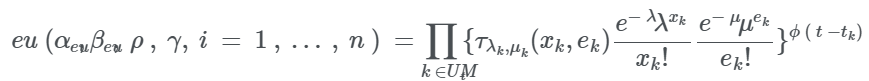

Onde:

ϕ(t) = e-ξt

* e: a constante matemática (2.71828).
* t: tempo decorrido desde que a partida foi jogada.
* ξ (xi): parâmetro positivo que controla com que rapidez o peso de jogos antigos decai.

As partidas recentes têm t pequeno, então exp (−𝜉𝑡) será mais próximo de 1 → peso alto. Partidas mais antigas têm t grande → peso muito menor.

É como se cada partida tivesse sido “jogada 𝜙(𝑡) vezes”, dando mais força para jogos recentes e quase apagando os muito antigos.

O peso entrará na função de verossimilhança. Em vez de tratar cada partida igualmente no somatório da probabilidade dos resultados, multiplicamos a contribuição de cada partida pela função de peso.

ξ(xi) pode ser calculado dessa maneira:

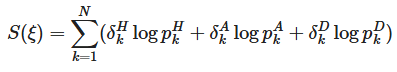

Em que:
* δ: resultado da partida (por exemplo: 1 se o time da casa venceu).
* p: probabilidades de resultados da partida.

In [ ]:
df_recent = df[df['Date'].dt.year >= 2024]
df_dixon_decay = df_recent.copy()
df_dixon_decay['time_diff'] = (df_dixon_decay['Date'] - df_dixon_decay['Date'].shift(1)).dt.days
df_dixon_decay = df_dixon_decay[['Home','Away','HG','AG', 'Res', 'time_diff']]
df_dixon_decay = df_dixon_decay.dropna()
df_dixon_decay

,Home,Away,HG,AG,Res,time_diff
4561,Internacional,Bahia,2.0,1.0,H,0.0
4562,Fluminense,Bragantino,2.0,2.0,D,1.0
4563,Sao Paulo,Fortaleza,1.0,2.0,A,0.0
4564,Athletico-PR,Cuiaba,4.0,0.0,H,0.0
4565,Atletico GO,Flamengo RJ,1.0,2.0,A,0.0
...,...,...,...,...,...,...
5144,Corinthians,Palmeiras,1.0,1.0,D,0.0
5145,Mirassol,Bahia,5.0,1.0,H,0.0
5146,Vitoria,Atletico-MG,1.0,0.0,H,0.0
5147,Internacional,Fortaleza,2.0,1.0,H,1.0


In [ ]:
# Ajuste de correlação de baixa contagem
def rho_correction(x, y, lambda_x, mu_y, rho):
    if x == 0 and y == 0:
        return 1 - (lambda_x*mu_y*rho)
    elif x == 0 and y == 1:
        return 1 + (lambda_x*rho)
    elif x == 1 and y == 0:
        return 1 + (mu_y*rho)
    elif x == 1 and y == 1:
        return 1 - rho
    else:
        return 1.0

# Estimação de parâmetros com decaimento temporal
# Partidas antigas recebem menos peso que partidas recentes
def solve_parameters_decay(dataset, xi=0.0065, debug=False, init_vals=None, options={'disp': True, 'maxiter':100}):
    teams = np.sort(dataset['Home'].unique())
    away_teams = np.sort(dataset['Away'].unique())

    n_teams = len(teams)

    # Inicialização dos parâmetros
    if init_vals is None:
        init_vals = np.concatenate((
            np.random.normal(1.0, 0.2, n_teams),  # ataque ~1
            np.random.normal(0.0, 0.2, n_teams),  # defesa ~0
            np.array([0.0, 0.3])                  # rho e gamma
        ))

    # Restrições: a média dos parâmetros de ataque deve ser ≈ 1
    constraints = [{'type':'eq', 'fun': lambda x: np.mean(x[:n_teams]) - 1.0}]

    # Bounds para evitar explosão e manter parâmetros em faixas realistas
    bounds = [(0.1, 3.0)]*n_teams + [(-1.0, 1.0)]*n_teams + [(-0.3,0.3), (0,1.5)]

    # Função verossimilhança com decay
    # Cada jogo é ponderado por exp(-xi * t), onde t é a "idade" da partida
    # Quanto mais antigo o jogo, menor sua influência.
    def dc_log_like_decay(x, y, alpha_x, beta_x, alpha_y, beta_y, rho, gamma, t, xi=xi):
        lambda_x = np.exp(alpha_x + beta_y + gamma)                         # gols esperados do mandante
        mu_y = np.exp(alpha_y + beta_x)                                     # gols esperados do visitante
        pmf_home = max(poisson.pmf(x, lambda_x), 1e-10)                     # prob. gols do mandante
        pmf_away = max(poisson.pmf(y, mu_y), 1e-10)                         # prob. gols do visitante
        rho_corr = max(rho_correction(x, y, lambda_x, mu_y, rho), 1e-10)    # ajuste dc
        return np.exp(-xi*t) * (np.log(rho_corr) + np.log(pmf_home) + np.log(pmf_away))

    # Função objetivo para o otimizador (soma negativa da log-verossimilhança)
    def estimate_parameters(params):
        attack_coefs = dict(zip(teams, params[:n_teams]))             # ataque
        defense_coefs = dict(zip(teams, params[n_teams:2*n_teams]))   # defesa
        rho, gamma = params[-2:]                                      # rho e vantegem de casa
        log_like = [
            dc_log_like_decay(row.HG, row.AG,
                              attack_coefs[row.Home], defense_coefs[row.Home],
                              attack_coefs[row.Away], defense_coefs[row.Away],
                              rho, gamma, row.time_diff)
            for row in dataset.itertuples()
        ]
        return -sum(log_like)

    # Otimização
    opt_output = minimize(
        estimate_parameters,
        init_vals,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options=options
    )

    if debug:
        return opt_output
    else:
        return dict(zip(
            ["attack_"+team for team in teams] +
            ["defence_"+team for team in teams] +
            ['rho', 'home_adv'],
            opt_output.x
        ))

In [ ]:
# Estimação com decaimento temporal (ξ (xi) - controla a taxa de esquecimento)
params_xi= solve_parameters_decay(df_dixon_decay, xi=0.0018)
params_xi

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1587.6536899678572
            Iterations: 57
            Function evaluations: 2971
            Gradient evaluations: 57


{'attack_Athletico-PR': np.float64(0.9066919196408552),
 'attack_Atletico GO': np.float64(0.6273578084847183),
 'attack_Atletico-MG': np.float64(0.9920209913259594),
 'attack_Bahia': np.float64(1.107187899834367),
 'attack_Botafogo RJ': np.float64(1.2391235167158994),
 'attack_Bragantino': np.float64(1.0050975498629546),
 'attack_Ceara': np.float64(0.8177639971409971),
 'attack_Corinthians': np.float64(1.0727558571006384),
 'attack_Criciuma': np.float64(0.9865007334878829),
 'attack_Cruzeiro': np.float64(1.0831335321972078),
 'attack_Cuiaba': np.float64(0.6195506614104207),
 'attack_Flamengo RJ': np.float64(1.3962212561059195),
 'attack_Fluminense': np.float64(0.8291948243285242),
 'attack_Fortaleza': np.float64(1.0446376333377747),
 'attack_Gremio': np.float64(0.9167752379556058),
 'attack_Internacional': np.float64(1.1004206166075956),
 'attack_Juventude': np.float64(0.9796284889233503),
 'attack_Mirassol': np.float64(1.4350684424525035),
 'attack_Palmeiras': np.float64(1.23889982252

In [ ]:
# Calcula médias de gols esperados para cada confronto
def calc_means(param_dict, homeTeam, awayTeam):
    return [np.exp(param_dict['attack_'+homeTeam] + param_dict['defence_'+awayTeam] + param_dict['home_adv']),
            np.exp(param_dict['attack_'+awayTeam] + param_dict['defence_'+homeTeam])]

# Simula matriz de probabilidades de resultados para uma partida
# Cria uma matriz de probabilidades combinadas, onde cada célula [i][j] é a probabilidade de: Time da casa fazer i gols e Time visitante fazer j gols
# O time mandante representa as linhas da matriz, o visitante representa as colunas e a diagonal são os empates
def dixon_coles_decay_simulate_match(params_dict, homeTeam, awayTeam, max_goals=10):
    team_avgs = calc_means(params_dict, homeTeam, awayTeam)

    # Probabilidades de gols 0..max_goals para cada time
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in team_avgs]

    # Matriz de probabilidades combinadas
    output_matrix = np.outer(np.array(team_pred[0]), np.array(team_pred[1]))

    # Correção Dixon-Coles aplicada apenas nos placares baixos (0-0, 0-1, 1-0, 1-1)
    correction_matrix = np.array([[rho_correction(home_goals, away_goals, team_avgs[0],
                                                   team_avgs[1], params_dict['rho']) for away_goals in range(2)]
                                   for home_goals in range(2)])
    output_matrix[:2,:2] = output_matrix[:2,:2] * correction_matrix
    return output_matrix

# ♟️ Elo Rating

Modelo alternativo para rankear times. Esse modelo funciona atribuindo para cada time uma pontuação e então adicionando ou subtraindo de acordo com as partidas que vão ocorrendo.

Este sistema calcula o resultado provável das partidas de um time contra outras equipes.

A diferença de rating entre os times determina quantos pontos eles podem ganhar ou perder. Visto que se espera que uma equipe com um rating muito mais alto vença, não ganha muitos pontos por uma vitória contra um plantel com um rating muito mais baixo.

---

**Fórmula**

Ra′ ​= Ra​ + K * (Sa ​− Ea​)

Em que:
* Ra′: novo rating após a partida.
* Ra: rating original antes da partida.
* K: peso do jogo.
* Sa: resultado do jogo (1 vitória, 0 derrota, 0.5 empate).
* Ea: resultado esperado da equipe j contra a equipe k. Calculado com base na diferença de pontuações Elo antes do jogo:

Ea = 1 / (1 + 10^((Rb - Ra) / 400))
* Ra = rating atual do time A
* Rb = rating atual do time B

O número 400 é um fator de escala usado no sistema Elo original (pode ser ajustado, mas 400 é o padrão).

In [ ]:
# Ajustando o dataset para pegar determinados dados e renomeando as colunas
df_elo = df[['Date', 'Home', 'Away', 'HG', 'AG']].copy()
df_elo.head()

,Date,Home,Away,HG,AG
0,2012-05-19,Palmeiras,Portuguesa,1.0,1.0
1,2012-05-19,Sport Recife,Flamengo RJ,1.0,1.0
2,2012-05-20,Figueirense,Nautico,2.0,1.0
3,2012-05-20,Botafogo RJ,Sao Paulo,4.0,2.0
4,2012-05-20,Corinthians,Fluminense,0.0,1.0


In [ ]:
# Probabilidade esperada de vitória
# P(A vencer B) = 1 / (1 + 10^((Rb - Ra)/400))
# Onde Ra e Rb são os ratings dos times
def elo_prob(Ra, Rb):
    return 1 / (1 + 10 ** ((Rb - Ra) / 400))

# Atualiza rating dos dois times após uma partida
# K = fator de ajuste
def update_elo(Ra, Rb, result, K=30):
    Ea = elo_prob(Ra, Rb)
    Eb = 1 - Ea
    Ra_new = Ra + K * (result - Ea)
    Rb_new = Rb + K * ((1 - result) - Eb)
    return Ra_new, Rb_new

# Função que transforma placar em resultado do jogo
def match_result(home_goals, away_goals):
    if home_goals > away_goals:
        return 1.0
    elif home_goals == away_goals:
        return 0.5
    else:
        return 0.0

In [ ]:
dict_score = {}       # Pontuação atual
dict_timeline = {}    # Histórico de pontuação

# Ano inicial (primeira partida do dataset)
year_now = int(df_elo.loc[0, 'Date'].year)

# Percorre todas as partidas
for idx, row in df_elo.iterrows():
    year = int(row['Date'].year)

    # quando muda o ano, guarda snapshot do ano anterior
    if year != year_now:
        dict_timeline[year_now] = dict_score.copy()
        year_now = year

    # Times e placares
    ht = str(row['Home']).strip()
    at = str(row['Away']).strip()
    hts = row['HG']
    ats = row['AG']

    # Se o time nunca jogou antes, começa com rating 1000
    if ht not in dict_score:
        dict_score[ht] = 1000.0
    if at not in dict_score:
        dict_score[at] = 1000.0

    # calcula resultado e atualiza ratings (USANDO APENAS score())
    r = match_result(hts, ats)

    # Atualiza ratings dos dois times
    new_ht, new_at = update_elo(dict_score[ht], dict_score[at], r)

    # Salva os novos ratings
    dict_score[ht] = new_ht
    dict_score[at] = new_at

# Salva snapshot do último ano
dict_timeline[year_now] = dict_score.copy()

In [ ]:
# Converte ratings em probabilidades e odds
def calc_odds(team_a, team_b, ratings):
    Ra = ratings[team_a]    # rating do time A
    Rb = ratings[team_b]    # rating do time B

    # Probabilidades baseadas na fórmula do Elo
    prob_a = elo_prob(Ra, Rb)
    prob_b = 1 - prob_a

    odd_a = 1 / prob_a
    odd_b = 1 / prob_b

    return print(f"Time {team_a} | Probabilidade de Vencer: {float(prob_a)} | Odd: {float(odd_a)}\nTime {team_b} | Probabilidade de Vencer: {float(prob_b)} | Odd: {float(odd_b)}")

# ⚽ Odds

## **Poisson**

In [ ]:
match_poisson = poisson_simulate_match(poisson_model, 'Atletico-MG', 'Ceara', max_goals=5)

prob_home_poisson = np.sum(np.tril(match_poisson, -1))
prob_away_poisson = np.sum(np.triu(match_poisson, 1))
prob_draw_poisson = np.sum(np.diag(match_poisson))

print("Home Win")
print("{:.5f}".format(prob_home_poisson))
print("Odd: {:.2f}".format(1/prob_home_poisson))
print()

print("Away Win")
print("{:.5f}".format(prob_away_poisson))
print("Odd: {:.2f}".format(1/prob_away_poisson))
print()

print("Draw")
print("{:.5f}".format(prob_draw_poisson))
print("Odd: {:.2f}".format(1/prob_draw_poisson))

Home Win
0.54980
Odd: 1.82

Away Win
0.18952
Odd: 5.28

Draw
0.25524
Odd: 3.92


## **Dixon-Coles**

In [ ]:
match_dixon = dixon_coles_simulate_match(params, 'Atletico-MG', 'Ceara', max_goals=5)

prob_home_dixon = np.sum(np.tril(match_dixon, -1))
prob_away_dixon = np.sum(np.triu(match_dixon, 1))
prob_draw_dixon = np.sum(np.diag(match_dixon))

print("Home Win")
print("{:.5f}".format(prob_home_dixon))
print("Odd: {:.2f}".format(1/prob_home_dixon))
print()

print("Away Win")
print("{:.5f}".format(prob_away_dixon))
print("Odd: {:.2f}".format(1/prob_away_dixon))
print()

print("Draw")
print("{:.5f}".format(prob_draw_dixon))
print("Odd: {:.2f}".format(1/prob_draw_dixon))

Home Win
0.39880
Odd: 2.51

Away Win
0.27789
Odd: 3.60

Draw
0.32221
Odd: 3.10


## **Dixon-Coles + Decay**

In [ ]:
match_dixon_decay = dixon_coles_decay_simulate_match(params_xi, 'Atletico-MG', 'Ceara', max_goals=5)

prob_home_dixon_decay = np.sum(np.tril(match_dixon_decay, -1))
prob_away_dixon_decay = np.sum(np.triu(match_dixon_decay, 1))
prob_draw_dixon_decay = np.sum(np.diag(match_dixon_decay))

print("Home Win")
print("{:.5f}".format(prob_home_dixon_decay))
print("Odd: {:.2f}".format(1/prob_home_dixon_decay))
print()

print("Away Win")
print("{:.5f}".format(prob_away_dixon_decay))
print("Odd: {:.2f}".format(1/prob_away_dixon_decay))
print()

print("Draw")
print("{:.5f}".format(prob_draw_dixon_decay))
print("Odd: {:.2f}".format(1/prob_draw_dixon_decay))

Home Win
0.41176
Odd: 2.43

Away Win
0.29017
Odd: 3.45

Draw
0.29604
Odd: 3.38


## **Elo Rating**

In [ ]:
calc_odds("Atletico-MG", "Ceara", dict_score)

Time Atletico-MG | Probabilidade de Vencer: 0.5418964429717716 | Odd: 1.8453710353143835
Time Ceara | Probabilidade de Vencer: 0.45810355702822836 | Odd: 2.1829125416251243


# 🧐 Métricas de Avaliação

## ❗**Funções Gerais**

In [ ]:
# Função para diferença percentual média
# ((Valor Final - Valor Inicial) / Valor Inicial) * 100
# Diferença entre o valor previsto (model) e o valor real (market)
def mean_percentage_diff(model, market):
    return np.mean(np.abs((model - market) / market)) * 100

# Função para calcular Brier Score
# (1/N) * Σ (F – O)²
# probs: probabilidades previstas pelo modelo (valores entre 0 e 1)
# obs: resultados observados (0 ou 1, para indicar se o evento ocorreu)
# (probs - obs) ** 2: calcula o erro quadrático para cada previsão
def brier_score(probs, obs):
    return np.mean((probs - obs) ** 2)

## ❗**Variáveis Gerais**

### Odds

#### Poisson e Dixon-Coles

In [ ]:
# Selecionar as odds conforme o jogo que está sendo observado
odds_casa1 = np.array([1.85, 3.50, 4.20])
odds_casa2 = np.array([1.87, 3.45, 5.00])
odds_casa3 = np.array([1.90, 3.35, 4.75])
odds_casa4 = np.array([1.80, 3.45, 4.60])
odds_casa5 = np.array([1.90, 3.35, 4.30])

# Converter odds para probabilidades implícitas
implied_probs_casa1 = 1 / odds_casa1
implied_probs_casa2 = 1 / odds_casa2
implied_probs_casa3 = 1 / odds_casa3
implied_probs_casa4= 1 / odds_casa4
implied_probs_casa5 = 1 / odds_casa5

# Normalizar
implied_probs_casa1 /= implied_probs_casa1.sum()
implied_probs_casa2 /= implied_probs_casa2.sum()
implied_probs_casa3 /= implied_probs_casa3.sum()
implied_probs_casa4 /= implied_probs_casa4.sum()
implied_probs_casa5 /= implied_probs_casa5.sum()

#### Elo Rating

In [ ]:
# Selecionar as odds conforme o jogo que está sendo observado
odds_casa1_elo = np.array([1.85, 4.20])
odds_casa2_elo = np.array([1.87, 5.00])
odds_casa3_elo = np.array([1.90, 4.75])
odds_casa4_elo = np.array([1.80, 4.60])
odds_casa5_elo = np.array([1.90, 4.30])

# Converter odds para probabilidades implícitas
implied_probs_casa1_elo = 1 / odds_casa1_elo
implied_probs_casa2_elo = 1 / odds_casa2_elo
implied_probs_casa3_elo = 1 / odds_casa3_elo
implied_probs_casa4_elo = 1 / odds_casa4_elo
implied_probs_casa5_elo = 1 / odds_casa5_elo

# Normalizar
implied_probs_casa1_elo /= implied_probs_casa1_elo.sum()
implied_probs_casa2_elo /= implied_probs_casa2_elo.sum()
implied_probs_casa3_elo /= implied_probs_casa3_elo.sum()
implied_probs_casa4_elo /= implied_probs_casa4_elo.sum()
implied_probs_casa5_elo /= implied_probs_casa5_elo.sum()

### Poisson

In [ ]:
# Probabilidades previstas pelo modelo Poisson
model_probs_poisson = np.array([prob_home_poisson, prob_draw_poisson, prob_away_poisson])  # [Home, Draw, Away]

# Normalizar
model_probs_poisson = model_probs_poisson / model_probs_poisson.sum()

### Dixon-Coles

In [ ]:
# Probabilidades previstas pelo modelo Dixon-Coles
model_probs_dixon = np.array([prob_home_dixon, prob_draw_dixon, prob_away_dixon])  # [Home, Draw, Away]

# Normalizar
model_probs_dixon = model_probs_dixon / model_probs_dixon.sum()

### Dixon-Coles + Decay

In [ ]:
# Probabilidades previstas pelo modelo Dixon-Coles + Decoy
model_probs_dixon_decay = np.array([prob_home_dixon_decay, prob_draw_dixon_decay, prob_away_dixon_decay])  # [Home, Draw, Away]

# Normalizar
model_probs_dixon_decay = model_probs_dixon_decay / model_probs_dixon_decay.sum()

### Elo Rating

In [ ]:
# Probabilidades previstas pelo modelo Elo
model_probs_elo = np.array([0.5418964429717716, 0.45810355702822836])  # [Home, Away]

# Normalizar
model_probs_elo /= model_probs_elo.sum()

## **Qui-Quadrado**

Verifica a associação entre variáveis categóricas. Ele analisa se a distribuição observada dos dados difere significativamente da distribuição esperada.

Na área de odds, para o cálculo do qui-quadrado o ideal é transformar as odds em porcentagens.

---

**Passos Realizar o Cálculo**

1. Fórmula duas hipóteses. Como:
* H0 (hipótese nula): não há viés (as distribuições são iguais, ou independentes).
* H1 (hipótese alternativa): há viés (as distribuições são diferentes, ou associadas).

2. Calcula as frequências esperadas observando uma tabela: (Total da linha × Total da coluna) / Total geral.

3. O valor de X² é calculado pela soma das diferenças ao quadrado entre as frequências observadas (O) e esperadas (E), divididas pelas frequências esperadas: **X² = ∑ (O – E)² / E**.

4. Calcula o grau de liberdade: (número de linhas - 1) x (número de colunas  - 1).

5. Define o nível de significância, normalmente, em estudos se utiliza 0.05.

6. Toma a decisão: se o valor de X² for maior que o valor crítico de distribuição, rejeita-se a hipótese nula.

### Poisson

In [ ]:
# Partidas analisadas
# Precisa multiplicar pelo número de partidas analisadas, pois a biblioteca espera as frequências e não as probabilidades
n_poisson = len(df_poisson)

# f_obs: frequências observadas em cada categoria
# f_exp: frequências esperadas em cada categoria

# Teste qui-quadrado Poisson vs Casa 1
chi2_casa1, p_casa1 = chisquare(f_obs=implied_probs_casa1 * n_poisson, f_exp=model_probs_poisson * n_poisson)

# Teste qui-quadrado Poisson vs Casa 2
chi2_casa2, p_casa2 = chisquare(f_obs=implied_probs_casa2 * n_poisson, f_exp=model_probs_poisson * n_poisson)

# Teste qui-quadrado Poisson vs Casa 3
chi2_casa3, p_casa3 = chisquare(f_obs=implied_probs_casa3 * n_poisson, f_exp=model_probs_poisson * n_poisson)

# Teste qui-quadrado Poisson vs Casa 4
chi2_casa4, p_casa4 = chisquare(f_obs=implied_probs_casa4 * n_poisson, f_exp=model_probs_poisson * n_poisson)

# Teste qui-quadrado Poisson vs Casa 5
chi2_casa5, p_casa5 = chisquare(f_obs=implied_probs_casa5 * n_poisson, f_exp=model_probs_poisson * n_poisson)

print("Modelo:", model_probs_poisson)
print("Probabilidades implícitas Casa 1:", implied_probs_casa1)
print(f"Qui-quadrado Casa 1: {chi2_casa1:.4f}, p-valor: {p_casa1:.4f}\n")

print("Probabilidades implícitas Casa 2:", implied_probs_casa2)
print(f"Qui-quadrado Casa 2: {chi2_casa2:.4f}, p-valor: {p_casa2:.4f}\n")

print("Probabilidades implícitas Casa 3:", implied_probs_casa3)
print(f"Qui-quadrado Casa 3: {chi2_casa3:.4f}, p-valor: {p_casa3:.4f}\n")

print("Probabilidades implícitas Casa 4:", implied_probs_casa4)
print(f"Qui-quadrado Casa 4: {chi2_casa4:.4f}, p-valor: {p_casa4:.4f}\n")

print("Probabilidades implícitas Casa 5:", implied_probs_casa5)
print(f"Qui-quadrado Casa 5: {chi2_casa5:.4f}, p-valor: {p_casa5:.4f}")

Modelo: [0.55280704 0.25663646 0.1905565 ]
Probabilidades implícitas Casa 1: [0.50785973 0.26844015 0.22370012]
Qui-quadrado Casa 1: 51.2950, p-valor: 0.0000

Probabilidades implícitas Casa 2: [0.52191277 0.28289185 0.19519538]
Qui-quadrado Casa 2: 23.3021, p-valor: 0.0000

Probabilidades implícitas Casa 3: [0.50834598 0.28831563 0.20333839]
Qui-quadrado Casa 3: 42.9619, p-valor: 0.0000

Probabilidades implícitas Casa 4: [0.52272727 0.27272727 0.20454545]
Qui-quadrado Casa 4: 18.9099, p-valor: 0.0001

Probabilidades implícitas Casa 5: [0.49775397 0.28230822 0.2199378 ]
Qui-quadrado Casa 5: 64.7787, p-valor: 0.0000


### Dixon-Coles

In [ ]:
# Partidas analisadas
# Precisa multiplicar pelo número de partidas analisadas, pois a biblioteca espera as frequências e não as probabilidades
n_dixon = len(df_dixon)

# f_obs: frequências observadas em cada categoria
# f_exp: frequências esperadas em cada categoria

# Teste qui-quadrado Dixon-Coles vs Casa 1
chi2_casa1, p_casa1 = chisquare(f_obs=implied_probs_casa1 * n_dixon, f_exp=model_probs_dixon * n_dixon)

# Teste qui-quadrado Dixon-Coles vs Casa 2
chi2_casa2, p_casa2 = chisquare(f_obs=implied_probs_casa2 * n_dixon, f_exp=model_probs_dixon * n_dixon)

# Teste qui-quadrado Dixon-Coles vs Casa 3
chi2_casa3, p_casa3 = chisquare(f_obs=implied_probs_casa3 * n_dixon, f_exp=model_probs_dixon * n_dixon)

# Teste qui-quadrado Dixon-Coles vs Casa 4
chi2_casa4, p_casa4 = chisquare(f_obs=implied_probs_casa4 * n_dixon, f_exp=model_probs_dixon * n_dixon)

# Teste qui-quadrado Dixon-Coles vs Casa 5
chi2_casa5, p_casa5 = chisquare(f_obs=implied_probs_casa5 * n_dixon, f_exp=model_probs_dixon * n_dixon)

print("Modelo:", model_probs_dixon)
print("Probabilidades implícitas Casa 1:", implied_probs_casa1)
print(f"Qui-quadrado Casa 1: {chi2_casa1:.4f}, p-valor: {p_casa1:.4f}\n")

print("Probabilidades implícitas Casa 2:", implied_probs_casa2)
print(f"Qui-quadrado Casa 2: {chi2_casa2:.4f}, p-valor: {p_casa2:.4f}\n")

print("Probabilidades implícitas Casa 3:", implied_probs_casa3)
print(f"Qui-quadrado Casa 3: {chi2_casa3:.4f}, p-valor: {p_casa3:.4f}\n")

print("Probabilidades implícitas Casa 4:", implied_probs_casa4)
print(f"Qui-quadrado Casa 4: {chi2_casa4:.4f}, p-valor: {p_casa4:.4f}\n")

print("Probabilidades implícitas Casa 5:", implied_probs_casa5)
print(f"Qui-quadrado Casa 5: {chi2_casa5:.4f}, p-valor: {p_casa5:.4f}")

Modelo: [0.3992366  0.32256667 0.27819673]
Probabilidades implícitas Casa 1: [0.50785973 0.26844015 0.22370012]
Qui-quadrado Casa 1: 29.0446, p-valor: 0.0000

Probabilidades implícitas Casa 2: [0.52191277 0.28289185 0.19519538]
Qui-quadrado Casa 2: 39.6628, p-valor: 0.0000

Probabilidades implícitas Casa 3: [0.50834598 0.28831563 0.20333839]
Qui-quadrado Casa 3: 31.5699, p-valor: 0.0000

Probabilidades implícitas Casa 4: [0.52272727 0.27272727 0.20454545]
Qui-quadrado Casa 4: 38.5190, p-valor: 0.0000

Probabilidades implícitas Casa 5: [0.49775397 0.28230822 0.2199378 ]
Qui-quadrado Casa 5: 24.4644, p-valor: 0.0000


### Dixon-Coles + Decay

In [ ]:
# Partidas analisadas
# Precisa multiplicar pelo número de partidas analisadas, pois a biblioteca espera as frequências e não as probabilidades
n_dixon_decay = len(df_dixon_decay)

# f_obs: frequências observadas em cada categoria
# f_exp: frequências esperadas em cada categoria

# Teste qui-quadrado Dixon-Coles + Decoy vs Casa 1
chi2_casa1, p_casa1 = chisquare(f_obs=implied_probs_casa1 * n_dixon_decay, f_exp=model_probs_dixon_decay * n_dixon_decay)

# Teste qui-quadrado Dixon-Coles + Decoy vs Casa 2
chi2_casa2, p_casa2 = chisquare(f_obs=implied_probs_casa2 * n_dixon_decay, f_exp=model_probs_dixon_decay * n_dixon_decay)

# Teste qui-quadrado Dixon-Coles + Decoy vs Casa 3
chi2_casa3, p_casa3 = chisquare(f_obs=implied_probs_casa3 * n_dixon_decay, f_exp=model_probs_dixon_decay * n_dixon_decay)

# Teste qui-quadrado Dixon-Coles + Decoy vs Casa 4
chi2_casa4, p_casa4 = chisquare(f_obs=implied_probs_casa4 * n_dixon_decay, f_exp=model_probs_dixon_decay * n_dixon_decay)

# Teste qui-quadrado Dixon-Coles + Decoy vs Casa 5
chi2_casa5, p_casa5 = chisquare(f_obs=implied_probs_casa5 * n_dixon_decay, f_exp=model_probs_dixon_decay * n_dixon_decay)

print("Modelo:", model_probs_dixon_decay)
print("Probabilidades implícitas Casa 1:", implied_probs_casa1)
print(f"Qui-quadrado Casa 1: {chi2_casa1:.4f}, p-valor: {p_casa1:.4f}\n")

print("Probabilidades implícitas Casa 2:", implied_probs_casa2)
print(f"Qui-quadrado Casa 2: {chi2_casa2:.4f}, p-valor: {p_casa2:.4f}\n")

print("Probabilidades implícitas Casa 3:", implied_probs_casa3)
print(f"Qui-quadrado Casa 3: {chi2_casa3:.4f}, p-valor: {p_casa3:.4f}\n")

print("Probabilidades implícitas Casa 4:", implied_probs_casa4)
print(f"Qui-quadrado Casa 4: {chi2_casa4:.4f}, p-valor: {p_casa4:.4f}\n")

print("Probabilidades implícitas Casa 5:", implied_probs_casa5)
print(f"Qui-quadrado Casa 5: {chi2_casa5:.4f}, p-valor: {p_casa5:.4f}")

Modelo: [0.41259957 0.29664231 0.29075812]
Probabilidades implícitas Casa 1: [0.50785973 0.26844015 0.22370012]
Qui-quadrado Casa 1: 23.6025, p-valor: 0.0000

Probabilidades implícitas Casa 2: [0.52191277 0.28289185 0.19519538]
Qui-quadrado Casa 2: 35.8721, p-valor: 0.0000

Probabilidades implícitas Casa 3: [0.50834598 0.28831563 0.20333839]
Qui-quadrado Casa 3: 28.6568, p-valor: 0.0000

Probabilidades implícitas Casa 4: [0.52272727 0.27272727 0.20454545]
Qui-quadrado Casa 4: 33.4486, p-valor: 0.0000

Probabilidades implícitas Casa 5: [0.49775397 0.28230822 0.2199378 ]
Qui-quadrado Casa 5: 20.8840, p-valor: 0.0000


### Elo Rating

In [ ]:
# Partidas analisadas
# Precisa multiplicar pelo número de partidas analisadas, pois a biblioteca espera as frequências e não as probabilidades
n_elo = len(df_elo)

# f_obs: frequências observadas em cada categoria
# f_exp: frequências esperadas em cada categoria

# Teste qui-quadrado Elo vs Casa 1
chi2_casa1, p_casa1 = chisquare(f_obs=implied_probs_casa1_elo * n_elo, f_exp=model_probs_elo * n_elo)

# Teste qui-quadrado Elo vs Casa 2
chi2_casa2, p_casa2 = chisquare(f_obs=implied_probs_casa2_elo * n_elo, f_exp=model_probs_elo * n_elo)

# Teste qui-quadrado Elo vs Casa 3
chi2_casa3, p_casa3 = chisquare(f_obs=implied_probs_casa3_elo * n_elo, f_exp=model_probs_elo * n_elo)

# Teste qui-quadrado Elo vs Casa 4
chi2_casa4, p_casa4 = chisquare(f_obs=implied_probs_casa4_elo * n_elo, f_exp=model_probs_elo * n_elo)

# Teste qui-quadrado Elo vs Casa 5
chi2_casa5, p_casa5 = chisquare(f_obs=implied_probs_casa5_elo * n_elo, f_exp=model_probs_elo * n_elo)

print("Modelo:", model_probs_elo)
print("Probabilidades implícitas Casa 1:", implied_probs_casa1_elo)
print(f"Qui-quadrado Casa 1: {chi2_casa1:.4f}, p-valor: {p_casa1:.4f}\n")

print("Probabilidades implícitas Casa 2:", implied_probs_casa2_elo)
print(f"Qui-quadrado Casa 2: {chi2_casa2:.4f}, p-valor: {p_casa2:.4f}\n")

print("Probabilidades implícitas Casa 3:", implied_probs_casa3_elo)
print(f"Qui-quadrado Casa 3: {chi2_casa3:.4f}, p-valor: {p_casa3:.4f}\n")

print("Probabilidades implícitas Casa 4:", implied_probs_casa4_elo)
print(f"Qui-quadrado Casa 4: {chi2_casa4:.4f}, p-valor: {p_casa4:.4f}\n")

print("Probabilidades implícitas Casa 5:", implied_probs_casa5_elo)
print(f"Qui-quadrado Casa 5: {chi2_casa5:.4f}, p-valor: {p_casa5:.4f}")

Modelo: [0.54189644 0.45810356]
Probabilidades implícitas Casa 1: [0.69421488 0.30578512]
Qui-quadrado Casa 1: 481.2246, p-valor: 0.0000

Probabilidades implícitas Casa 2: [0.72780204 0.27219796]
Qui-quadrado Casa 2: 716.8493, p-valor: 0.0000

Probabilidades implícitas Casa 3: [0.71428571 0.28571429]
Qui-quadrado Casa 3: 616.4011, p-valor: 0.0000

Probabilidades implícitas Casa 4: [0.71875 0.28125]
Qui-quadrado Casa 4: 648.7398, p-valor: 0.0000

Probabilidades implícitas Casa 5: [0.69354839 0.30645161]
Qui-quadrado Casa 5: 477.0225, p-valor: 0.0000


## **Diferença Percentual Média**

Permite medir a variação percentual entre dois valores. É uma maneira de expressar a mudança relativa entre um valor inicial e um valor final.

---

**Fórmula**

Diferença Percentual = ((Valor Final - Valor Inicial) / Valor Inicial) * 100.

Para calcular a DPM para vários valores de uma única vez, deve-se calcular a diferença para cada caso, utilizando da fórmula acima, somar as diferenças e então dividir pela quantidade de casos analisados.

### Poisson

In [ ]:
diff_casa1 = mean_percentage_diff(model_probs_poisson, implied_probs_casa1)
diff_casa2 = mean_percentage_diff(model_probs_poisson, implied_probs_casa2)
diff_casa3 = mean_percentage_diff(model_probs_poisson, implied_probs_casa3)
diff_casa4 = mean_percentage_diff(model_probs_poisson, implied_probs_casa4)
diff_casa5 = mean_percentage_diff(model_probs_poisson, implied_probs_casa5)

print(f"Diferença percentual média Poisson vs Casa 1: {diff_casa1:.2f}%")
print(f"Diferença percentual média Poisson vs Casa 2: {diff_casa2:.2f}%")
print(f"Diferença percentual média Poisson vs Casa 3: {diff_casa3:.2f}%")
print(f"Diferença percentual média Poisson vs Casa 4: {diff_casa4:.2f}%")
print(f"Diferença percentual média Poisson vs Casa 5: {diff_casa5:.2f}%")

Diferença percentual média Poisson vs Casa 1: 9.35%
Diferença percentual média Poisson vs Casa 2: 5.86%
Diferença percentual média Poisson vs Casa 3: 8.67%
Diferença percentual média Poisson vs Casa 4: 6.16%
Diferença percentual média Poisson vs Casa 5: 11.17%


### Dixon-Coles

In [ ]:
diff_casa1 = mean_percentage_diff(model_probs_dixon, implied_probs_casa1)
diff_casa2 = mean_percentage_diff(model_probs_dixon, implied_probs_casa2)
diff_casa3 = mean_percentage_diff(model_probs_dixon, implied_probs_casa3)
diff_casa4 = mean_percentage_diff(model_probs_dixon, implied_probs_casa4)
diff_casa5 = mean_percentage_diff(model_probs_dixon, implied_probs_casa5)

print(f"Diferença percentual média Dixon-Coles vs Casa 1: {diff_casa1:.2f}%")
print(f"Diferença percentual média Dixon-Coles vs Casa 2: {diff_casa2:.2f}%")
print(f"Diferença percentual média Dixon-Coles vs Casa 3: {diff_casa3:.2f}%")
print(f"Diferença percentual média Dixon-Coles vs Casa 4: {diff_casa4:.2f}%")
print(f"Diferença percentual média Dixon-Coles vs Casa 5: {diff_casa5:.2f}%")

Diferença percentual média Dixon-Coles vs Casa 1: 21.97%
Diferença percentual média Dixon-Coles vs Casa 2: 26.68%
Diferença percentual média Dixon-Coles vs Casa 3: 23.39%
Diferença percentual média Dixon-Coles vs Casa 4: 25.97%
Diferença percentual média Dixon-Coles vs Casa 5: 20.18%


### Dixon-Coles + Decay

In [ ]:
diff_casa1 = mean_percentage_diff(model_probs_dixon_decay, implied_probs_casa1)
diff_casa2 = mean_percentage_diff(model_probs_dixon_decay, implied_probs_casa2)
diff_casa3 = mean_percentage_diff(model_probs_dixon_decay, implied_probs_casa3)
diff_casa4 = mean_percentage_diff(model_probs_dixon_decay, implied_probs_casa4)
diff_casa5 = mean_percentage_diff(model_probs_dixon_decay, implied_probs_casa5)

print(f"Diferença percentual média Dixon-Coles + Decay vs Casa 1: {diff_casa1:.2f}%")
print(f"Diferença percentual média Dixon-Coles + Decay vs Casa 2: {diff_casa2:.2f}%")
print(f"Diferença percentual média Dixon-Coles + Decay vs Casa 3: {diff_casa3:.2f}%")
print(f"Diferença percentual média Dixon-Coles + Decay vs Casa 4: {diff_casa4:.2f}%")
print(f"Diferença percentual média Dixon-Coles + Decay vs Casa 5: {diff_casa5:.2f}%")

Diferença percentual média Dixon-Coles + Decay vs Casa 1: 19.75%
Diferença percentual média Dixon-Coles + Decay vs Casa 2: 24.92%
Diferença percentual média Dixon-Coles + Decay vs Casa 3: 21.57%
Diferença percentual média Dixon-Coles + Decay vs Casa 4: 24.00%
Diferença percentual média Dixon-Coles + Decay vs Casa 5: 18.13%


### Elo Rating

In [ ]:
diff_casa1 = mean_percentage_diff(model_probs_elo, implied_probs_casa1_elo)
diff_casa2 = mean_percentage_diff(model_probs_elo, implied_probs_casa2_elo)
diff_casa3 = mean_percentage_diff(model_probs_elo, implied_probs_casa3_elo)
diff_casa4 = mean_percentage_diff(model_probs_elo, implied_probs_casa4_elo)
diff_casa5 = mean_percentage_diff(model_probs_elo, implied_probs_casa5_elo)

print(f"Diferença percentual média Elo Rating vs Casa 1: {diff_casa1:.2f}%")
print(f"Diferença percentual média Elo Rating vs Casa 2: {diff_casa2:.2f}%")
print(f"Diferença percentual média Elo Rating vs Casa 3: {diff_casa3:.2f}%")
print(f"Diferença percentual média Elo Rating vs Casa 4: {diff_casa4:.2f}%")
print(f"Diferença percentual média Elo Rating vs Casa 5: {diff_casa5:.2f}%")

Diferença percentual média Elo Rating vs Casa 1: 35.88%
Diferença percentual média Elo Rating vs Casa 2: 46.92%
Diferença percentual média Elo Rating vs Casa 3: 42.24%
Diferença percentual média Elo Rating vs Casa 4: 43.74%
Diferença percentual média Elo Rating vs Casa 5: 35.68%


## **Brier Score**

Utilizada para medir a precisão de previsões probabilísticas. Quantifica a diferença entre as probabilidades previstas e os resultados reais.

O resultado é um valor que varia de 0 a 1, onde 0 indica previsões perfeitas e 1 indica previsões completamente erradas. Quanto mais baixo, maior a precisão da previsão, probabilidades previstas estavam muito próximas dos resultados reais. Enquanto um valor mais alto sugere uma performance ruim, probabilidades previstas estavam bem distantes dos resultados reais, indicando grande erro nas previsões.

---

**Fórmula**

Brier Score = (1/N) * Σ (F – O)²

Onde:
* N: número total de previsões
* F: probabilidade prevista para o evento i
* O: resultado observado (0 ou 1)

### Poisson e Dixon-Coles

In [ ]:
# Resultado real do jogo
obs = np.array([0, 0, 1])  # [Home, Draw, Away]

# Calcular Brier Score para cada modelo
bs_poisson = brier_score(model_probs_poisson, obs)
bs_dc = brier_score(model_probs_dixon, obs)
bs_dc_decay = brier_score(model_probs_dixon_decay, obs)

print(f"Brier Score Poisson: {bs_poisson:.4f}")
print(f"Brier Score Dixon-Coles: {bs_dc:.4f}")
print(f"Brier Score Dixon-Coles + Decay: {bs_dc_decay:.4f}")


Brier Score Poisson: 0.3422
Brier Score Dixon-Coles: 0.2615
Brier Score Dixon-Coles + Decay: 0.2538


### Elo Rating

In [ ]:
# Resultado Real
obs_elo = np.array([0, 1])

# Calcular Brier Score
bs_elo = brier_score(model_probs_elo, obs_elo)

print(f"Brier Score Elo: {bs_elo:.4f}")

Brier Score Elo: 0.2937


## **Curvas de Confiabilidade**

Plota a probabilidade real/empírica em relação à probabilidade estimada/prevista.

Valores abaixo da curva sugerem superestimação, enquanto valores acima da curva sugerem subestimação.

---

**Fórmula**

calibração = previsão média/real médio

### Poisson

In [ ]:
probabilities_poisson = []
observed_results_poisson = []

# Itera sobre todas as linhas do DataFrame
for index, row in df_poisson.iterrows():
    home_team = row['Home']
    away_team = row['Away']
    home_goals = row['HG']
    away_goals = row['AG']

    # Simula matriz de gols
    match_matrix = poisson_simulate_match(poisson_model, home_team, away_team, max_goals=5)

    # Probabilidades de cada resultado
    prob_home = np.sum(np.tril(match_matrix, -1))
    prob_away = np.sum(np.triu(match_matrix, 1))
    prob_draw = np.sum(np.diag(match_matrix))

    # Normaliza para garantir que a soma das probabilidades seja 1
    total = prob_home + prob_draw + prob_away
    prob_vector = np.array([prob_home, prob_draw, prob_away]) / total
    probabilities_poisson.append(prob_vector)

    # Resultado real (one-hot)
    if home_goals > away_goals:
        observed_results_poisson.append([1, 0, 0])
    elif home_goals < away_goals:
        observed_results_poisson.append([0, 0, 1])
    else:
        observed_results_poisson.append([0, 1, 0])

# Converte listas em arrays
probabilities_poisson = np.array(probabilities_poisson)
observed_results_poisson = np.array(observed_results_poisson)

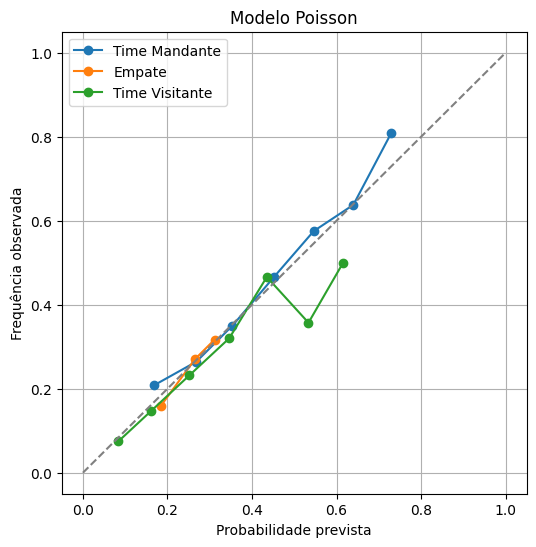

In [ ]:
categories = ['Time Mandante', 'Empate', 'Time Visitante']
plt.figure(figsize=(6,6))

# Itera sobre cada categoria
for i, cat in enumerate(categories):
    # Calcula a curva de calibração usando sklearn
    # prob_true = frequência observada do evento dentro de cada bin
    # prob_pred = probabilidade média prevista dentro de cada bin
    prob_true, prob_pred = calibration_curve(
        observed_results_poisson[:,i],    # resultados reais da categoria i
        probabilities_poisson[:,i],       # probabilidades previstas da categoria i
        n_bins=10,                        # número de bins para agrupamento
        strategy='uniform'                # bins de tamanho uniforme
    )
    plt.plot(prob_pred, prob_true, marker='o', label=cat)

# Linha ideal
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.title("Modelo Poisson")
plt.legend()
plt.grid(True)
plt.show()

### Dixon-Coles

In [ ]:
probabilities_dixon = []
observed_results_dixon = []

# Itera sobre todas as linhas do DataFrame
for index, row in df_dixon.iterrows():
    home_team = row['Home']
    away_team = row['Away']
    home_goals = row['HG']
    away_goals = row['AG']

    # Simula matriz de gols
    match_matrix = dixon_coles_simulate_match(params, home_team, away_team, max_goals=5)

    # Probabilidades de cada resultado
    prob_home = np.sum(np.tril(match_matrix, -1))
    prob_away = np.sum(np.triu(match_matrix, 1))
    prob_draw = np.sum(np.diag(match_matrix))

    # Normaliza para garantir que a soma das probabilidades seja 1
    total = prob_home + prob_draw + prob_away
    prob_vector = np.array([prob_home, prob_draw, prob_away]) / total
    probabilities_dixon.append(prob_vector)

    # Resultado real (one-hot)
    if home_goals > away_goals:
        observed_results_dixon.append([1, 0, 0])
    elif home_goals < away_goals:
        observed_results_dixon.append([0, 0, 1])
    else:
        observed_results_dixon.append([0, 1, 0])

# Converte listas em arrays
probabilities_dixon = np.array(probabilities_dixon)
observed_results_dixon = np.array(observed_results_dixon)

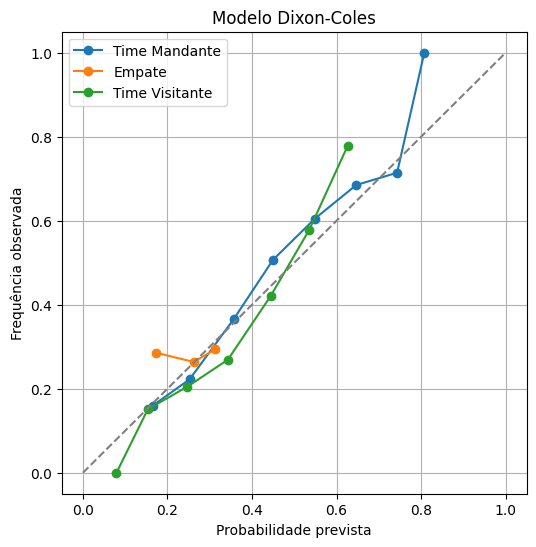

In [ ]:
categories = ['Time Mandante', 'Empate', 'Time Visitante']
plt.figure(figsize=(6,6))

# Itera sobre cada categoria
for i, cat in enumerate(categories):
    # Calcula a curva de calibração usando sklearn
    # prob_true = frequência observada do evento dentro de cada bin
    # prob_pred = probabilidade média prevista dentro de cada bin
    prob_true, prob_pred = calibration_curve(
        observed_results_dixon[:,i],    # resultados reais da categoria i
        probabilities_dixon[:,i],       # probabilidades previstas da categoria i
        n_bins=10,                      # número de bins para agrupamento
        strategy='uniform'              # bins de tamanho uniforme
    )
    plt.plot(prob_pred, prob_true, marker='o', label=cat)

# Linha ideal
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.title("Modelo Dixon-Coles")
plt.legend()
plt.grid(True)
plt.show()

### Dixon-Coles + Decay

In [ ]:
probabilities_dixon_decay = []
observed_results_dixon_decay = []

# Itera sobre todas as linhas do DataFrame
for index, row in df_dixon_decay.iterrows():
    home_team = row['Home']
    away_team = row['Away']
    home_goals = row['HG']
    away_goals = row['AG']

    # Simula matriz de gols
    match_matrix = dixon_coles_decay_simulate_match(params_xi, home_team, away_team, max_goals=5)

    # Probabilidades de cada resultado
    prob_home = np.sum(np.tril(match_matrix, -1))
    prob_away = np.sum(np.triu(match_matrix, 1))
    prob_draw = np.sum(np.diag(match_matrix))

    # Normaliza para garantir que a soma das probabilidades seja 1
    total = prob_home + prob_draw + prob_away
    prob_vector = np.array([prob_home, prob_draw, prob_away]) / total
    probabilities_dixon_decay.append(prob_vector)

    # Resultado real (one-hot)
    if home_goals > away_goals:
        observed_results_dixon_decay.append([1, 0, 0])
    elif home_goals < away_goals:
        observed_results_dixon_decay.append([0, 0, 1])
    else:
        observed_results_dixon_decay.append([0, 1, 0])

# Converte listas em arrays
probabilities_dixon_decay = np.array(probabilities_dixon_decay)
observed_results_dixon_decay = np.array(observed_results_dixon_decay)

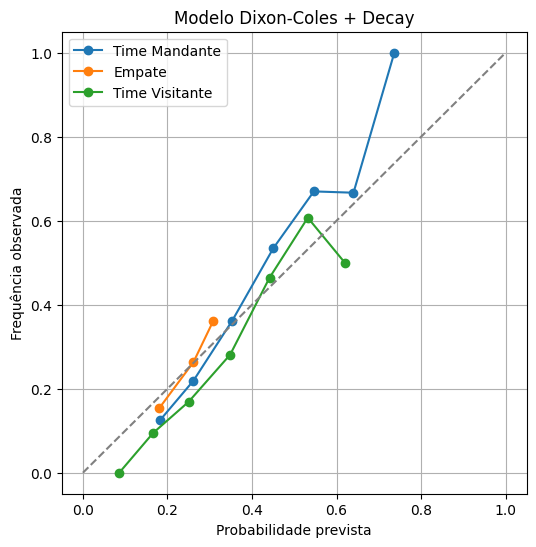

In [ ]:
categories = ['Time Mandante', 'Empate', 'Time Visitante']
plt.figure(figsize=(6,6))

# Itera sobre cada categoria
for i, cat in enumerate(categories):
    # Calcula a curva de calibração usando sklearn
    # prob_true = frequência observada do evento dentro de cada bin
    # prob_pred = probabilidade média prevista dentro de cada bin
    prob_true, prob_pred = calibration_curve(
        observed_results_dixon_decay[:,i],    # resultados reais da categoria i
        probabilities_dixon_decay[:,i],       # probabilidades previstas da categoria i
        n_bins=10,                            # número de bins para agrupamento
        strategy='uniform'                    # bins de tamanho uniforme
    )
    plt.plot(prob_pred, prob_true, marker='o', label=cat)

# Linha ideal
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.title("Modelo Dixon-Coles + Decay")
plt.legend()
plt.grid(True)
plt.show()

### Elo Rating

In [ ]:
probabilities_elo = []
observed_results_elo = []

# Itera sobre todas as linhas do DataFrame
for index, row in df_elo.iterrows():
    home_team = row['Home']
    away_team = row['Away']
    home_goals = row['HG']
    away_goals = row['AG']

    # Calcula probabilidades pelo Elo
    prob_home = elo_prob(dict_score[home_team], dict_score[away_team])
    prob_away = 1 - prob_home

    # Ignorando empates
    if home_goals == away_goals:
        continue

    probabilities_elo.append([prob_home, prob_away])

    # Resultado real (one-hot)
    if home_goals > away_goals:
        observed_results_elo.append([1, 0])
    else:
        observed_results_elo.append([0, 1])

probabilities_elo = np.array(probabilities_elo)
observed_results_elo = np.array(observed_results_elo)

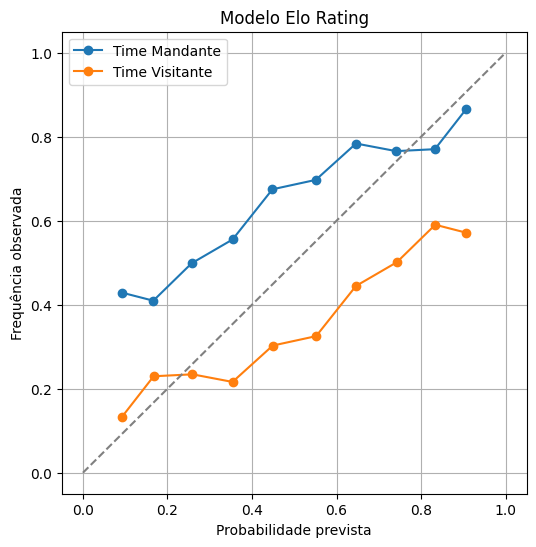

In [ ]:
categories = ['Time Mandante', 'Time Visitante']
plt.figure(figsize=(6,6))

for i, cat in enumerate(categories):
    # Calcula a curva de calibração usando sklearn
    # prob_true = frequência observada do evento dentro de cada bin
    # prob_pred = probabilidade média prevista dentro de cada bin
    prob_true, prob_pred = calibration_curve(
        observed_results_elo[:,i],    # resultados reais da categoria i
        probabilities_elo[:,i],       # probabilidades previstas da categoria i
        n_bins=10,                    # número de bins para agrupamento
        strategy='uniform'            # bins de tamanho uniforme
    )
    plt.plot(prob_pred, prob_true, marker='o', label=cat)

# Linha ideal
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.title("Modelo Elo Rating")
plt.legend()
plt.grid(True)
plt.show()

# 📖 Referências

## Poisson

https://www.youtube.com/watch?v=yPVnGKRSzRI

https://dashee87.github.io/football/python/predicting-football-results-with-statistical-modelling/

https://sol.sbc.org.br/index.php/eniac/article/view/18237/18071

https://periodicos.ufop.br/rest/article/view/3337/2600

https://www.teses.usp.br/teses/disponiveis/45/45133/tde-19072012-112940/publico/Poison_Bayes_Futebol_e_DeFinetti.pdf

https://ufs.emnuvens.com.br/ReviSe/article/view/13637/11837

## Dixon-Coles

https://dashee87.github.io/football/python/predicting-football-results-with-statistical-modelling-dixon-coles-and-time-weighting/

https://github.com/dashee87/blogScripts/blob/master/Jupyter/2018-09-13-predicting-football-results-with-statistical-modelling-dixon-coles-and-time-weighting.ipynb

https://kucharski.substack.com/p/can-we-predict-who-will-win-a-football

https://pena.lt/y/2021/06/24/predicting-football-results-using-python-and-dixon-and-coles/

## Elo Rating

https://www.kaggle.com/code/thomasstokes/custom-football-elo-rating

https://www.chess.com/pt-BR/terms/sistema-rating-elo-xadrez

https://www.sciencedirect.com/science/article/pii/S036013151630080X

https://stanislav-stankovic.medium.com/elo-rating-system-6196cc59941e

## Métricas de Avaliação

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chisquare.html

https://medium.com/@ale.alves/teste-qui-quadrado-o-que-%C3%A9-quando-us%C3%A1-lo-e-como-implementar-em-python-63124afb7add

https://thalesferraz.medium.com/como-fazer-um-teste-chi-quadrado-em-python-a4cc115bd204

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html

https://scikit-learn.org/stable/modules/generated/sklearn.calibration.calibration_curve.html

https://scikit-learn.org/stable/modules/calibration.html

https://www.geeksforgeeks.org/machine-learning/probability-calibration-curve-in-scikit-learn/